## Data

### Real Data

In [1]:
from simulator_simple import simulate

true_parameters = [460, 1, 490, 0.8]

desorption, time = simulate(true_parameters)

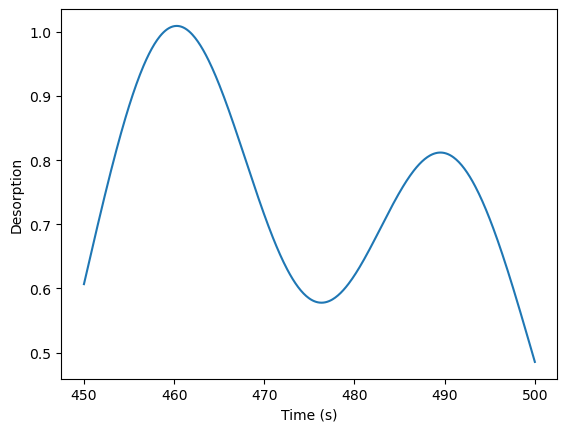

In [2]:
import matplotlib.pyplot as plt

plt.plot(time, desorption)
plt.xlabel("Time (s)")
plt.ylabel("Desorption")
plt.show()

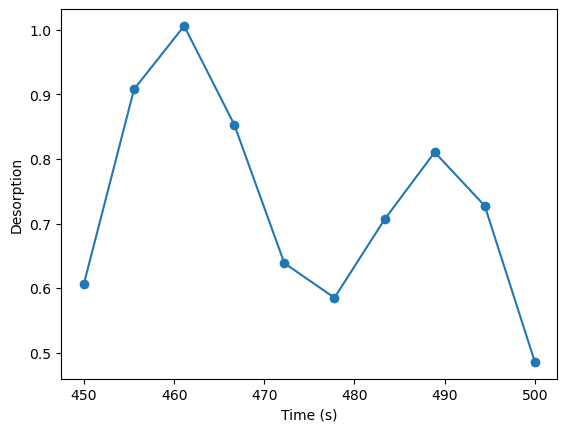

In [3]:
import numpy as np
n_weights = 10
exp_times = np.linspace(450, 500, n_weights)
exp_observation = np.interp(exp_times, time, desorption)
plt.plot(exp_times, exp_observation, marker='o')
plt.xlabel("Time (s)")
plt.ylabel("Desorption")
plt.show()

### Training data

In [4]:
import numpy as np

n_samples = 100
# x = np.random.rand(n_samples, 4) * np.array([2e-3, 1.5, 1e-6, 1.5])
x = np.random.rand(n_samples, 4) 

# x0 and x2 varies between 450 and 500
# x1 and x3 varies between 0 and 1.5
x[:, 0] = x[:, 0] * 50 + 450
x[:, 2] = x[:, 2]* 50 + 450
x[:, 1] = x[:, 1] * 1.5
x[:, 3] = x[:, 3] * 1.5

In [5]:
desorptions = []
times = []
for xi in x:
    print(f"Simulating for parameters: {xi}")
    desorption, time = simulate(xi)
    desorptions.append(desorption)
    times.append(time)

Simulating for parameters: [4.91550049e+02 2.85467725e-01 4.67215810e+02 1.29988794e+00]
Simulating for parameters: [4.83866014e+02 2.42823384e-01 4.93359522e+02 5.13680404e-01]
Simulating for parameters: [460.4260491    0.584053   453.53554828   1.24965394]
Simulating for parameters: [480.36606466   0.6174127  482.68313205   0.53831076]
Simulating for parameters: [4.53383204e+02 3.29097586e-01 4.98721765e+02 1.46744297e+00]
Simulating for parameters: [4.91846665e+02 1.48275042e+00 4.89255902e+02 2.55058703e-01]
Simulating for parameters: [4.87109935e+02 1.58908811e-01 4.95678649e+02 1.81831614e-01]
Simulating for parameters: [486.38967161   1.25873987 497.16788895   0.61207716]
Simulating for parameters: [475.58239937   0.8435887  451.40043747   1.49673681]
Simulating for parameters: [4.87899261e+02 6.90173296e-01 4.67553767e+02 1.84568658e-01]
Simulating for parameters: [4.69941660e+02 3.90539134e-01 4.84488005e+02 1.46665611e+00]
Simulating for parameters: [4.73048073e+02 6.55247511

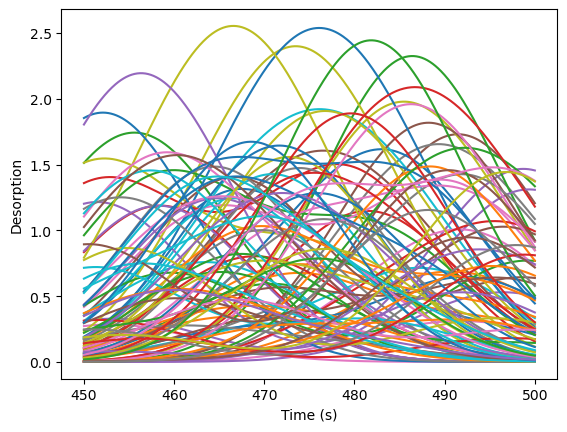

In [6]:
for t, d in zip(times, desorptions):
    plt.plot(t, d)
plt.xlabel("Time (s)")
plt.ylabel("Desorption")
plt.show()

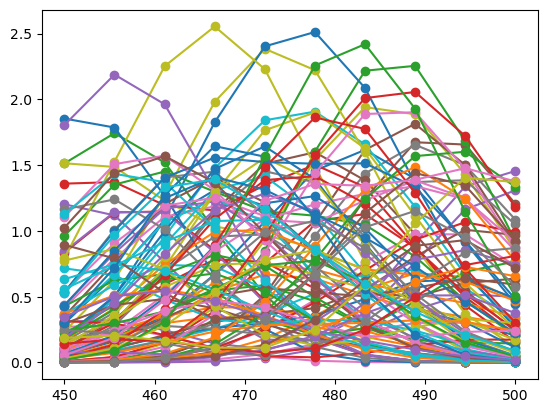

In [7]:
y = []
for i, des in enumerate(desorptions):
    exp_desorption = np.interp(exp_times, time, des)

    plt.plot(exp_times, exp_desorption, marker='o', label=f'Simulation {i+1}')
    y.append(exp_desorption)


In [8]:
# make sure x and y are pytorch tensors
import torch
x = torch.tensor(x, dtype=torch.float32)
y = torch.tensor(y, dtype=torch.float32)
x.shape, y.shape

/tmp/ipykernel_478174/2523727512.py:4: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  y = torch.tensor(y, dtype=torch.float32)


(torch.Size([100, 4]), torch.Size([100, 10]))

## Build emulator

In [9]:
from autoemulate import AutoEmulate

AutoEmulate.list_emulators()

,Emulator,PyTorch,Multioutput,Uncertainty_Quantification,Automatic_Differentiation
0,GaussianProcessMatern32,True,True,True,True
1,GaussianProcessRBF,True,True,True,True
2,RadialBasisFunctions,True,True,False,True
3,PolynomialRegression,True,True,False,True
4,MLP,True,True,False,True
5,EnsembleMLP,True,True,True,True


In [10]:
# Run AutoEmulate with default settings
ae = AutoEmulate(x, y, log_level="info", models=["GaussianProcessRBF"])

INFO    2026-01-16 13:05:00,564 - autoemulate - Comparing ['GaussianProcessRBF']
INFO    2026-01-16 13:05:00,565 - autoemulate - Running Model: GaussianProcessRBF: 1/1 (attempt 1/3)
INFO    2026-01-16 13:05:33,548 - autoemulate - Finished running Model: GaussianProcessRBF

INFO    2026-01-16 13:05:33,549 - autoemulate - Using metric 'r2' to determine best result.


In [11]:
ae.summarise()

,model_name,x_transforms,y_transforms,params,r2_test,r2_test_std,rmse_test,rmse_test_std,r2_train,r2_train_std,rmse_train,rmse_train_std
0,GaussianProcessRBF,[StandardizeTransform()],[StandardizeTransform()],"{'epochs': 50, 'lr': 0.5, 'likelihood_cls': <c...",0.984442,0.006345,0.056482,0.015116,0.999792,0.000028,0.007063,0.000372


In [12]:
best = ae.best_result()
print("Model with id: ", best.id, " performed best: ", best.model_name)

INFO    2026-01-16 13:05:33,623 - autoemulate - Using metric 'r2' to determine best result.
Model with id:  0  performed best:  GaussianProcessRBF


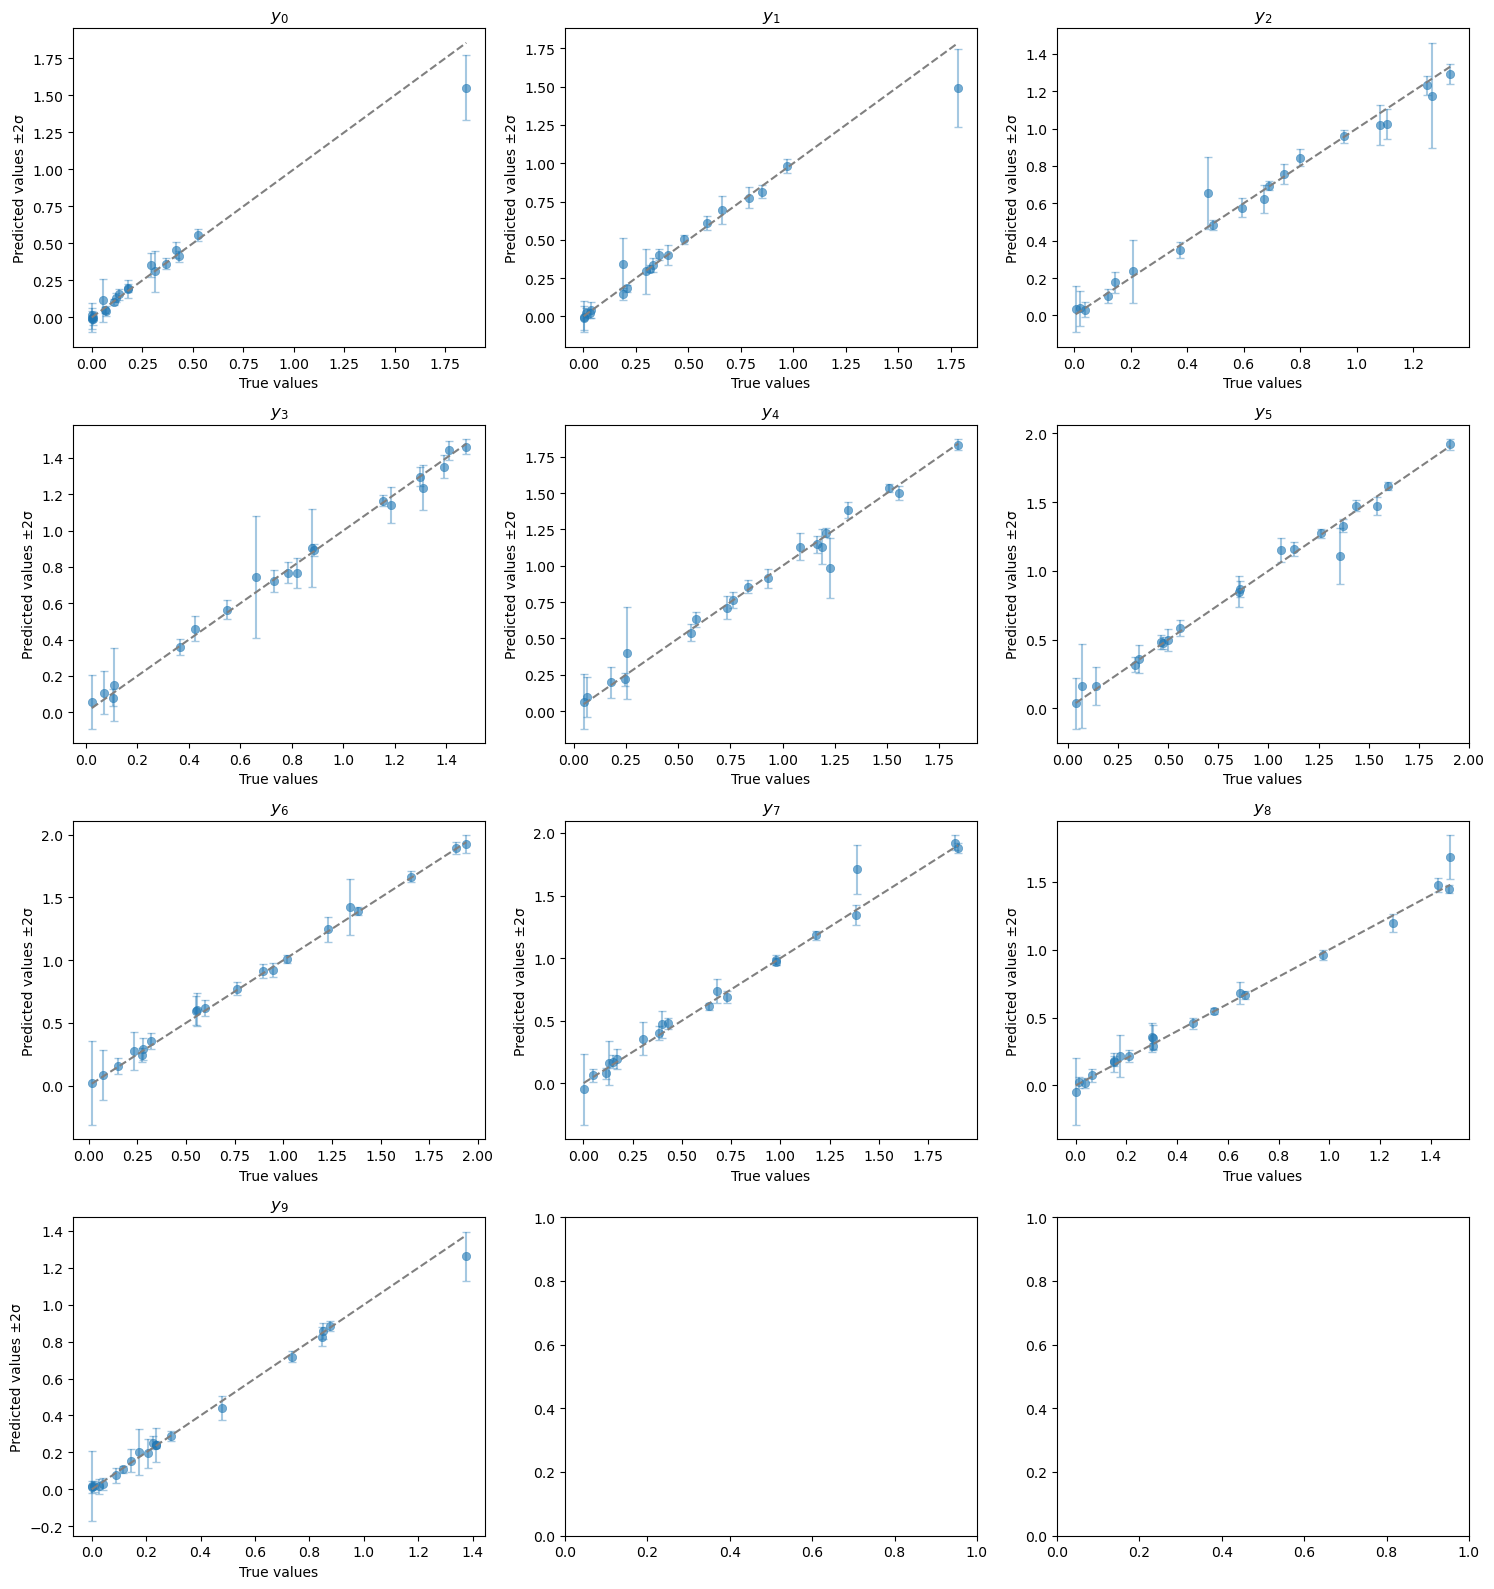

In [13]:
ae.plot_preds(best)

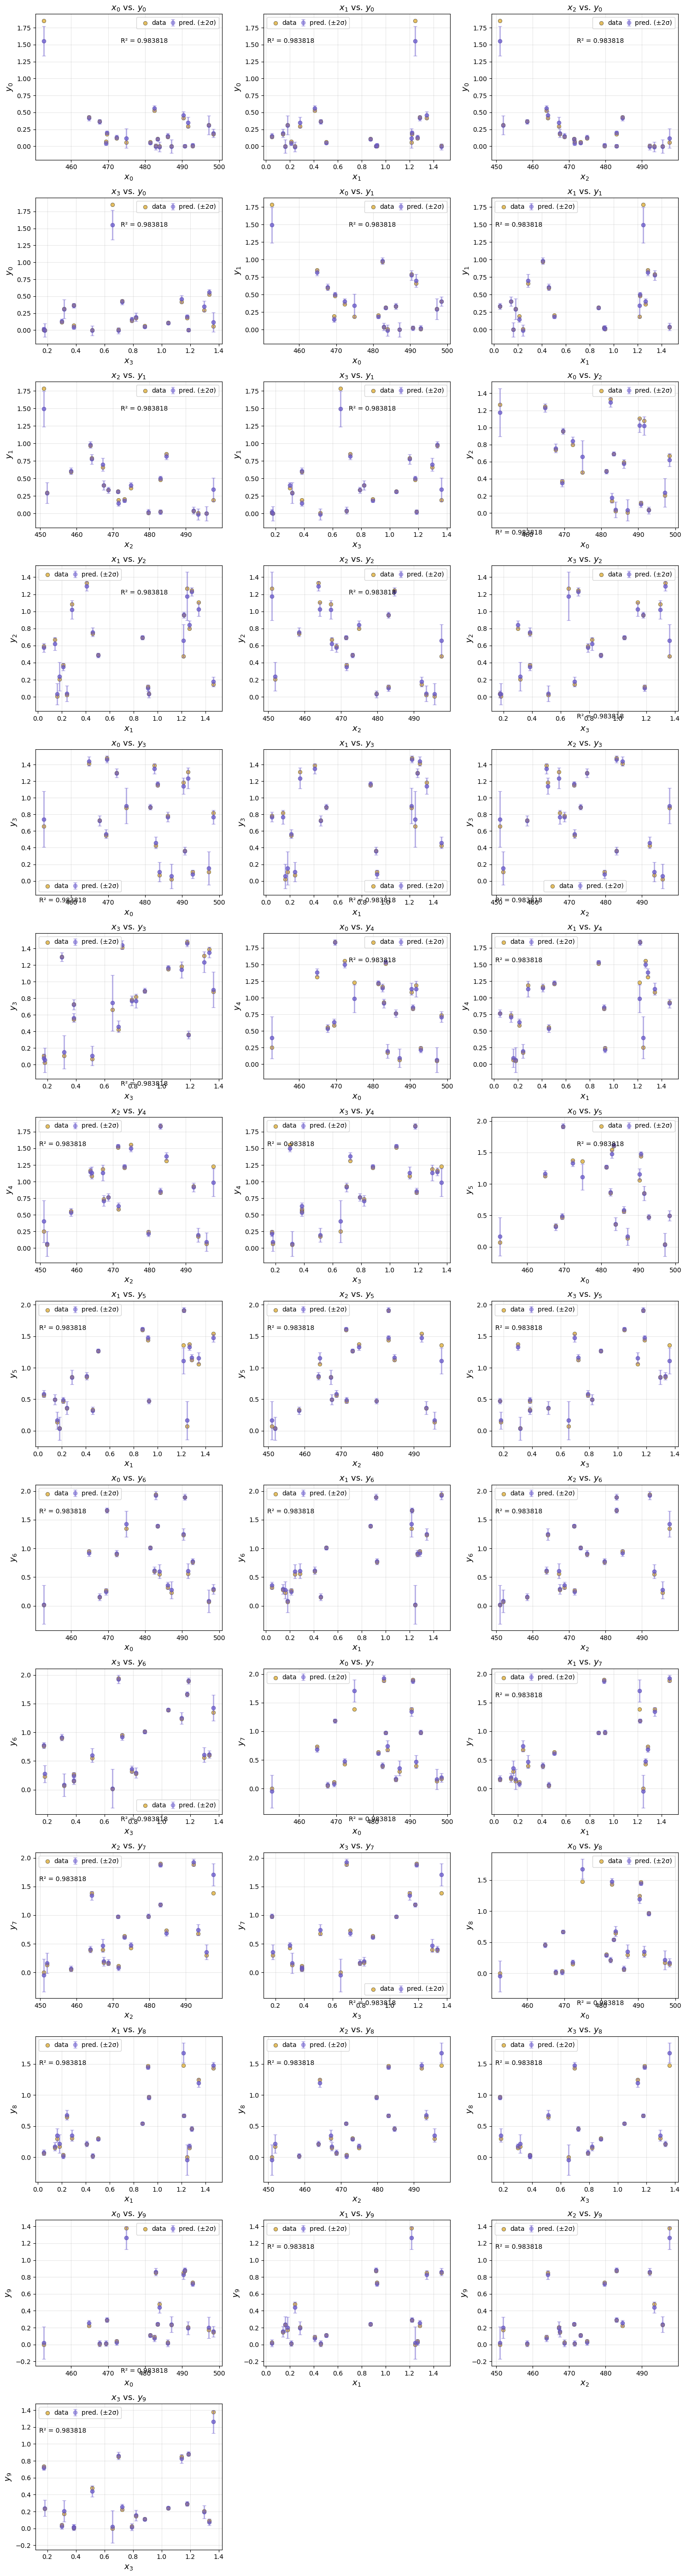

In [14]:
ae.plot(best)

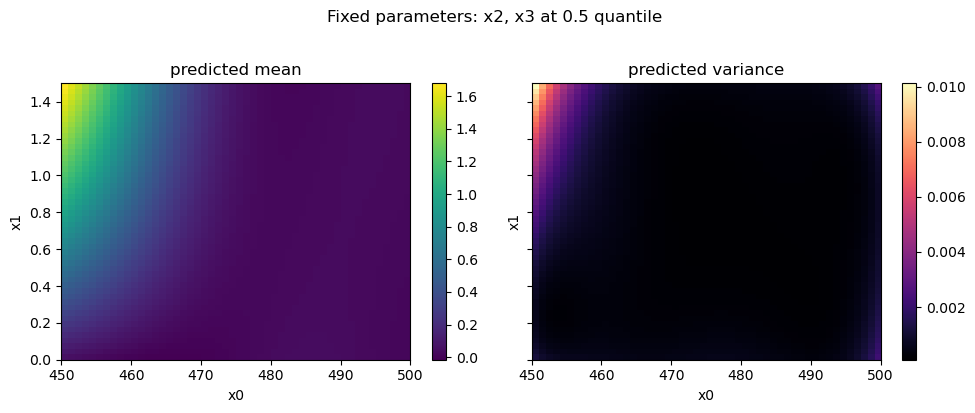

In [15]:
ae.plot_surface(best.model, parameters_range={"x0": [450, 500],"x1": [0, 1.5], "x2": [450, 500], "x3": [0, 1.5]}, quantile=0.5)

INFO    2026-01-16 13:05:37,656 - autoemulate - Using held out test data for calibration plot. To use different data, provide x_test and y_test.


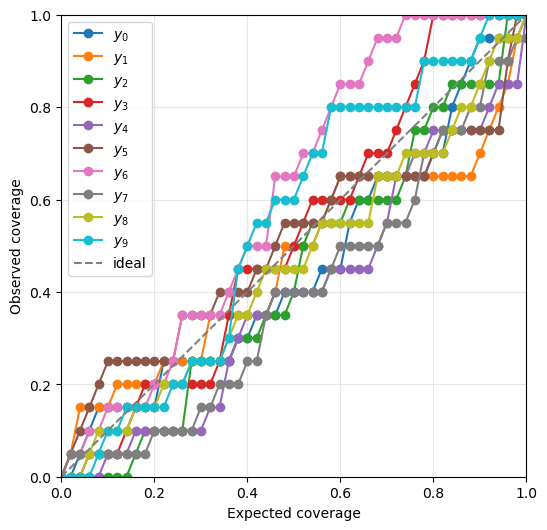

In [16]:
ae.plot_calibration(best.model)

In [17]:
x_test = torch.tensor([[460, 0.5, 490, 0.5]], dtype=torch.float32)

print(best.model.predict(x_test).mean)
print(best.model.predict(x_test).stddev)

tensor([[0.2900, 0.4261, 0.4738, 0.3955, 0.3104, 0.3085, 0.3964, 0.4818, 0.4647,
         0.3264]])
tensor([[0.0247, 0.0306, 0.0354, 0.0444, 0.0406, 0.0390, 0.0444, 0.0353, 0.0292,
         0.0233]])


In [18]:
# y_sim_test = [simulate(xi.numpy().astype(np.float32)) for xi in x_test]
y_sim_test = [simulate(xi.tolist()) for xi in x_test]

print("Simulator outputs:", y_sim_test[0][0].shape)


Simulator outputs: (500,)


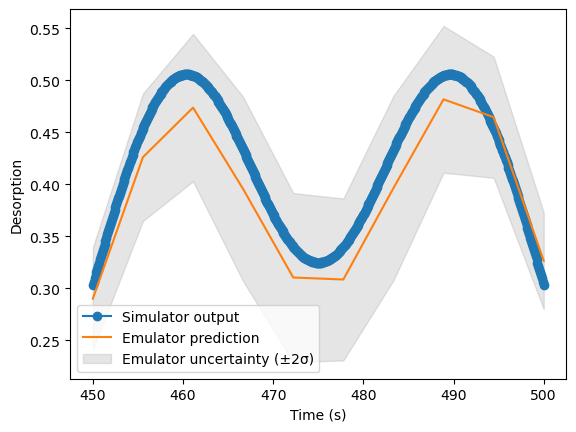

In [19]:
plt.plot(y_sim_test[0][1], y_sim_test[0][0], label='Simulator output', marker='o')
plt.plot(exp_times, best.model.predict(x_test).mean[0].detach().numpy(), label='Emulator prediction')
plt.fill_between(
    exp_times,
    best.model.predict(x_test).mean[0].detach().numpy() - 2 * best.model.predict(x_test).stddev[0].detach().numpy(),
    best.model.predict(x_test).mean[0].detach().numpy() + 2 * best.model.predict(x_test).stddev[0].detach().numpy(),
    color='gray',
    alpha=0.2,
    label='Emulator uncertainty (±2σ)'
)

plt.xlabel("Time (s)")
plt.ylabel("Desorption")
plt.legend()
plt.show()

## Saving the emulator

In [20]:
# Make a directory to save Emulator models
import os
path = "my_emulators"
if not os.path.exists(path):
    os.makedirs(path)

# The use_timestamp paramater ensures a new result is saved each time the save method is called
best_result_filepath = ae.save(best, path, use_timestamp=True)
print("Model and metadata saved to: ", best_result_filepath)

INFO    2026-01-16 13:05:38,347 - autoemulate - GaussianProcessRBF_0_20260116_130538.joblib saved to my_emulators/GaussianProcessRBF_0_20260116_130538
INFO    2026-01-16 13:05:38,355 - autoemulate - Metadata saved to my_emulators/GaussianProcessRBF_0_20260116_130538_metadata.csv
Model and metadata saved to:  my_emulators/GaussianProcessRBF_0_20260116_130538


## Bayesian calibration

In [21]:
from autoemulate.calibration.bayes import BayesianCalibration

bc = BayesianCalibration(
    best.model, 
    parameter_range={"x0": [450, 500],"x1": [0, 1.5], "x2": [450, 500], "x3": [0, 1.5]}, 
    observations={"desorption": torch.Tensor(exp_observation)}, 
    # specify noise as variance
    observation_noise=0.1**2
)

In [26]:
mcmc_emu = bc.run_mcmc(
    warmup_steps=10, 
    num_samples=50,
    num_chains=2
)

Warmup [1]:   0%|          | 0/60 [00:00, ?it/s]

Warmup [2]:   0%|          | 0/60 [00:00, ?it/s]

/home/remidm/miniconda3/envs/festim-emulate/lib/python3.12/site-packages/torch/utils/_device.py:103: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return func(*args, **kwargs)
/home/remidm/miniconda3/envs/festim-emulate/lib/python3.12/site-packages/torch/utils/_device.py:103: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return func(*args, **kwargs)


WARNING 2026-01-16 13:12:53,403 - py.warnings - /home/remidm/miniconda3/envs/festim-emulate/lib/python3.12/site-packages/autoemulate/calibration/bayes.py:189: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  else torch.tensor(observation_variance + self.model_discrepancy).to(



In [23]:
mcmc_emu.summary()

print(true_parameters)


                mean       std    median      5.0%     95.0%     n_eff     r_hat
        x0    459.15     12.97    452.41    452.25    491.31      4.10      1.60
        x1      0.60      0.25      0.50      0.41      1.23      6.02      1.15
        x2    470.51     11.35    472.76    451.38    488.90      8.55      2.22
        x3      0.51      0.33      0.38      0.09      1.02      6.59      1.04

Number of divergences: 10
[460, 1, 490, 0.8]


tensor([[0.2900, 0.4261, 0.4738, 0.3955, 0.3104, 0.3085, 0.3964, 0.4818, 0.4647,
         0.3264]])
tensor([[0.0247, 0.0306, 0.0354, 0.0444, 0.0406, 0.0390, 0.0444, 0.0353, 0.0292,
         0.0233]])


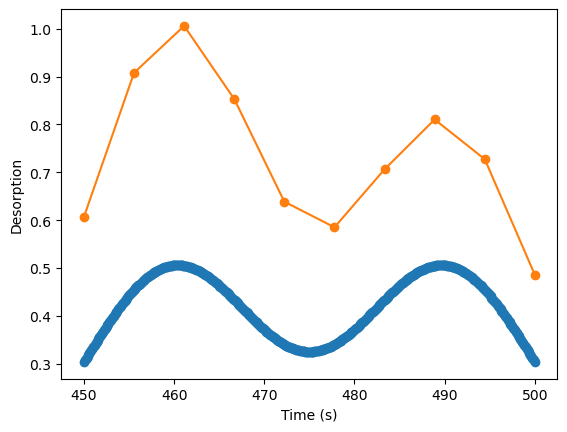

In [25]:
x_found = torch.tensor([[459.15, 0.60, 470.51, 0.51]], dtype=torch.float32)

print(best.model.predict(x_test).mean)
print(best.model.predict(x_test).stddev)

plt.plot(y_sim_test[0][1], y_sim_test[0][0], label='Simulator output', marker='o')
plt.plot(exp_times, exp_observation, marker='o')
plt.xlabel("Time (s)")
plt.ylabel("Desorption")
plt.show()